# Lab | Week 7 | Day 5 | In God we trust, everyone else bring the data
## John Adams

## Part 2: Pairwise Group Comparisons
### Step 4: Compare Groups Using t-tests

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_ind, fisher_exact, false_discovery_control

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RNG = np.random.default_rng(42)

In [127]:
df = pd.read_csv("Data/marketing_data.csv")

print(f"shape: {df.shape}")
print(f"groups: {df['platform'].unique().tolist()}")

shape: (1800, 17)
groups: ['Google Ads', 'TikTok Ads', 'Meta Ads']


In [128]:
def cohens_d(a, b):
    pooled_std = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return (b.mean() - a.mean()) / pooled_std if pooled_std > 0 else 0.0


def interpret_effect_size(d):
    d = abs(d)
    if d < 0.2:
        return "negligible"
    elif d < 0.5:
        return "small"
    elif d < 0.8:
        return "medium"
    return "large"


def compare_groups_ttest(data, metric, group_col="platform"):
    clean = data[[group_col, metric]].replace([np.inf, -np.inf], np.nan).dropna()
    groups = sorted(clean[group_col].unique())
    rows = []

    for group_a, group_b in combinations(groups, 2):
        values_a = clean[clean[group_col] == group_a][metric]
        values_b = clean[clean[group_col] == group_b][metric]

        # Welch's t-test: does not assume the two groups have equal variance,
        # a safer default for real-world marketing metrics like CPA and ROAS
        t_stat, p_value = ttest_ind(values_a, values_b, equal_var=False)
        mean_a, mean_b = values_a.mean(), values_b.mean()
        diff = mean_b - mean_a
        pct_diff = (diff / mean_a) * 100 if mean_a != 0 else np.nan
        d = cohens_d(values_a, values_b)

        rows.append({
            "metric": metric,
            "group_a": group_a,
            "group_b": group_b,
            "mean_a": mean_a,
            "mean_b": mean_b,
            "difference": diff,
            "pct_difference": pct_diff,
            "t_statistic": t_stat,
            "p_value": p_value,
            "cohens_d": d,
            "effect_size": interpret_effect_size(d),
            "significant": p_value < 0.05,
        })

    return pd.DataFrame(rows)

In [129]:
cpa_results = compare_groups_ttest(df, "CPA")
roas_results = compare_groups_ttest(df, "ROAS")

print("=== CPA (primary metric): pairwise significance ===")
print(f"comparisons: {len(cpa_results)}, significant at alpha=0.05: {cpa_results['significant'].sum()}")
for _, row in cpa_results.iterrows():
    print(f"{row['group_a']} vs {row['group_b']}: p={row['p_value']:.4g}, "
          f"Cohen's d={row['cohens_d']:.2f} ({row['effect_size']})")
print()

print("=== ROAS: pairwise significance ===")
print(f"comparisons: {len(roas_results)}, significant at alpha=0.05: {roas_results['significant'].sum()}")
for _, row in roas_results.iterrows():
    print(f"{row['group_a']} vs {row['group_b']}: p={row['p_value']:.4g}, "
          f"Cohen's d={row['cohens_d']:.2f} ({row['effect_size']})")
print()

cpa_results.round(4)

=== CPA (primary metric): pairwise significance ===
comparisons: 3, significant at alpha=0.05: 3
Google Ads vs Meta Ads: p=7.473e-28, Cohen's d=-0.60 (medium)
Google Ads vs TikTok Ads: p=2.725e-51, Cohen's d=-0.88 (large)
Meta Ads vs TikTok Ads: p=6.494e-09, Cohen's d=-0.35 (small)

=== ROAS: pairwise significance ===
comparisons: 3, significant at alpha=0.05: 3
Google Ads vs Meta Ads: p=5.385e-21, Cohen's d=0.53 (medium)
Google Ads vs TikTok Ads: p=5.165e-32, Cohen's d=0.81 (large)
Meta Ads vs TikTok Ads: p=7.642e-08, Cohen's d=0.34 (small)



,metric,group_a,group_b,mean_a,mean_b,difference,pct_difference,t_statistic,p_value,cohens_d,effect_size,significant
0,CPA,Google Ads,Meta Ads,64.0646,39.0968,-24.9678,-38.9728,11.2167,0.0,-0.6026,medium,True
1,CPA,Google Ads,TikTok Ads,64.0646,29.1966,-34.8680,-54.4263,15.8662,0.0,-0.8845,large,True
2,CPA,Meta Ads,TikTok Ads,39.0968,29.1966,-9.9002,-25.3222,5.8512,0.0,-0.3548,small,True


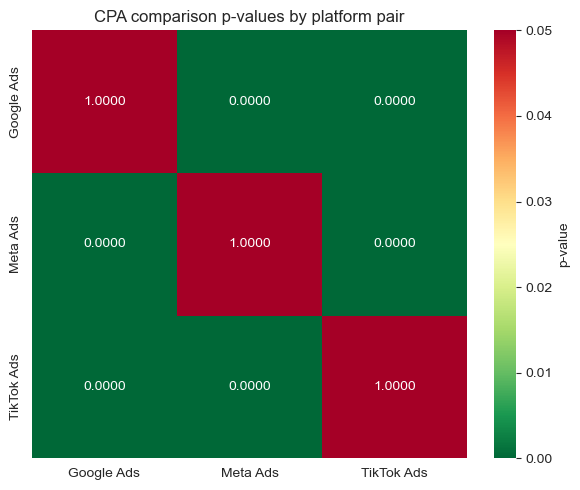

In [130]:
platforms = sorted(df["platform"].unique())
p_matrix = pd.DataFrame(1.0, index=platforms, columns=platforms)

for _, row in cpa_results.iterrows():
    p_matrix.loc[row["group_a"], row["group_b"]] = row["p_value"]
    p_matrix.loc[row["group_b"], row["group_a"]] = row["p_value"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(p_matrix, annot=True, fmt=".4f", cmap="RdYlGn_r", vmin=0, vmax=0.05,
            cbar_kws={"label": "p-value"}, ax=ax)
ax.set_title("CPA comparison p-values by platform pair")

plt.tight_layout()
plt.savefig("Outputs/metric_comparison_heatmap.png", dpi=150)
plt.show()

### Step 5: Compare Binary Outcomes Using Fisher's Exact Test

In [131]:
conversion_summary = df.groupby("platform").agg(
    conversions=("conversions", "sum"),
    clicks=("clicks", "sum"),
).reset_index()
conversion_summary["non_conversions"] = conversion_summary["clicks"] - conversion_summary["conversions"]

conversion_summary

,platform,conversions,clicks,non_conversions
0,Google Ads,131098,2936149,2805051
1,Meta Ads,73262,1596736,1523474
2,TikTok Ads,122452,2599931,2477479


In [132]:
def compare_groups_fisher(summary, group_col="platform"):
    rows = []
    groups = sorted(summary[group_col].unique())

    for group_a, group_b in combinations(groups, 2):
        row_a = summary[summary[group_col] == group_a].iloc[0]
        row_b = summary[summary[group_col] == group_b].iloc[0]

        table = [
            [row_a["conversions"], row_a["non_conversions"]],
            [row_b["conversions"], row_b["non_conversions"]],
        ]
        odds_ratio, p_value = fisher_exact(table, alternative="two-sided")

        rate_a = row_a["conversions"] / row_a["clicks"]
        rate_b = row_b["conversions"] / row_b["clicks"]
        diff = rate_b - rate_a
        pct_diff = (diff / rate_a) * 100 if rate_a != 0 else np.nan

        rows.append({
            "group_a": group_a,
            "group_b": group_b,
            "conversions_a": row_a["conversions"],
            "conversions_b": row_b["conversions"],
            "rate_a": rate_a,
            "rate_b": rate_b,
            "difference": diff,
            "pct_difference": pct_diff,
            "odds_ratio": odds_ratio,
            "p_value": p_value,
            "significant": p_value < 0.05,
        })

    return pd.DataFrame(rows)


fisher_results = compare_groups_fisher(conversion_summary)

print(f"total comparisons: {len(fisher_results)}")
print(f"significant at alpha=0.05: {fisher_results['significant'].sum()}")
fisher_results.round(6)

total comparisons: 3
significant at alpha=0.05: 3


,group_a,group_b,conversions_a,conversions_b,rate_a,rate_b,difference,pct_difference,odds_ratio,p_value,significant
0,Google Ads,Meta Ads,131098,73262,0.044650,0.045882,0.001233,2.760848,0.971878,0.0,True
1,Google Ads,TikTok Ads,131098,122452,0.044650,0.047098,0.002449,5.483877,0.945582,0.0,True
2,Meta Ads,TikTok Ads,73262,122452,0.045882,0.047098,0.001216,2.649871,0.972944,0.0,True


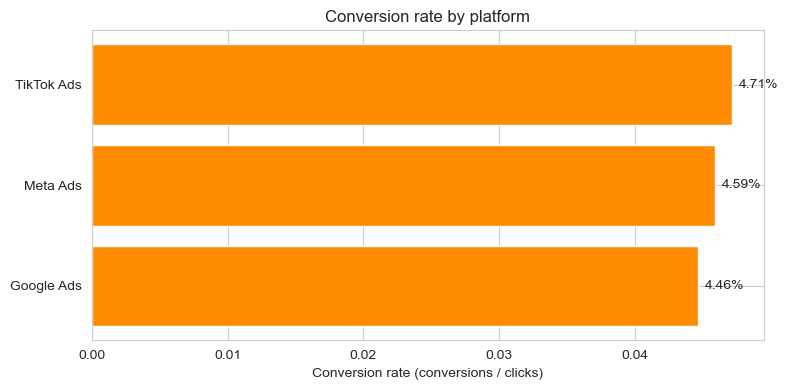

In [133]:
conversion_summary["conversion_rate"] = conversion_summary["conversions"] / conversion_summary["clicks"]
plot_data = conversion_summary.sort_values("conversion_rate")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(plot_data["platform"], plot_data["conversion_rate"], color="darkorange")

for bar, rate in zip(bars, plot_data["conversion_rate"]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f"{rate:.2%}", va="center")

ax.set_xlabel("Conversion rate (conversions / clicks)")
ax.set_title("Conversion rate by platform")

plt.tight_layout()
plt.savefig("Outputs/rate_comparison.png", dpi=150)
plt.show()

## Part 3: Multiple Comparisons Correction
### Step 6: Apply Multiple Comparisons Correction

In [134]:
alpha = 0.05
total_comparisons = len(cpa_results) + len(roas_results) + len(fisher_results)
expected_false_positives = total_comparisons * alpha

print(f"total comparisons run: {total_comparisons} "
      f"({len(cpa_results)} CPA t-tests + {len(roas_results)} ROAS t-tests + {len(fisher_results)} Fisher's tests)")
print(f"at alpha={alpha}, expected false positives by chance alone: {expected_false_positives:.2f}")
print("some of our 'significant' results above could be false alarms, not real differences.")

total comparisons run: 9 (3 CPA t-tests + 3 ROAS t-tests + 3 Fisher's tests)
at alpha=0.05, expected false positives by chance alone: 0.45
some of our 'significant' results above could be false alarms, not real differences.


In [135]:
alpha_bonferroni_cpa = alpha / len(cpa_results)
alpha_bonferroni_roas = alpha / len(roas_results)
alpha_bonferroni_fisher = alpha / len(fisher_results)

cpa_results["significant_bonferroni"] = cpa_results["p_value"] < alpha_bonferroni_cpa
roas_results["significant_bonferroni"] = roas_results["p_value"] < alpha_bonferroni_roas
fisher_results["significant_bonferroni"] = fisher_results["p_value"] < alpha_bonferroni_fisher

print(f"bonferroni alpha for CPA t-tests: {alpha_bonferroni_cpa:.6f}")
print(f"significant after bonferroni: {cpa_results['significant_bonferroni'].sum()} of {len(cpa_results)}")
print()
print(f"bonferroni alpha for ROAS t-tests: {alpha_bonferroni_roas:.6f}")
print(f"significant after bonferroni: {roas_results['significant_bonferroni'].sum()} of {len(roas_results)}")
print()
print(f"bonferroni alpha for fisher's tests: {alpha_bonferroni_fisher:.6f}")
print(f"significant after bonferroni: {fisher_results['significant_bonferroni'].sum()} of {len(fisher_results)}")

bonferroni alpha for CPA t-tests: 0.016667
significant after bonferroni: 3 of 3

bonferroni alpha for ROAS t-tests: 0.016667
significant after bonferroni: 3 of 3

bonferroni alpha for fisher's tests: 0.016667
significant after bonferroni: 3 of 3


In [136]:
cpa_results["p_value_fdr"] = false_discovery_control(cpa_results["p_value"], method="bh")
cpa_results["significant_fdr"] = cpa_results["p_value_fdr"] < alpha

roas_results["p_value_fdr"] = false_discovery_control(roas_results["p_value"], method="bh")
roas_results["significant_fdr"] = roas_results["p_value_fdr"] < alpha

fisher_results["p_value_fdr"] = false_discovery_control(fisher_results["p_value"], method="bh")
fisher_results["significant_fdr"] = fisher_results["p_value_fdr"] < alpha

print(f"significant after FDR (CPA): {cpa_results['significant_fdr'].sum()} of {len(cpa_results)}")
print(f"significant after FDR (ROAS): {roas_results['significant_fdr'].sum()} of {len(roas_results)}")
print(f"significant after FDR (fisher's, conversion rate): {fisher_results['significant_fdr'].sum()} of {len(fisher_results)}")
print("all comparisons tested against alpha = 0.05 after FDR adjustment")
print()
cpa_results[["group_a", "group_b", "p_value", "p_value_fdr", "significant_fdr"]].round(6)

significant after FDR (CPA): 3 of 3
significant after FDR (ROAS): 3 of 3
significant after FDR (fisher's, conversion rate): 3 of 3
all comparisons tested against alpha = 0.05 after FDR adjustment



,group_a,group_b,p_value,p_value_fdr,significant_fdr
0,Google Ads,Meta Ads,0.0,0.0,True
1,Google Ads,TikTok Ads,0.0,0.0,True
2,Meta Ads,TikTok Ads,0.0,0.0,True


In [137]:
correction_summary = pd.DataFrame([
    {
        "test_type": "t-test (CPA)",
        "uncorrected": cpa_results["significant"].sum(),
        "bonferroni": cpa_results["significant_bonferroni"].sum(),
        "fdr": cpa_results["significant_fdr"].sum(),
        "total_comparisons": len(cpa_results),
    },
    {
        "test_type": "t-test (ROAS)",
        "uncorrected": roas_results["significant"].sum(),
        "bonferroni": roas_results["significant_bonferroni"].sum(),
        "fdr": roas_results["significant_fdr"].sum(),
        "total_comparisons": len(roas_results),
    },
    {
        "test_type": "Fisher's (conversion rate)",
        "uncorrected": fisher_results["significant"].sum(),
        "bonferroni": fisher_results["significant_bonferroni"].sum(),
        "fdr": fisher_results["significant_fdr"].sum(),
        "total_comparisons": len(fisher_results),
    },
])

correction_summary

,test_type,uncorrected,bonferroni,fdr,total_comparisons
0,t-test (CPA),3,3,3,3
1,t-test (ROAS),3,3,3,3
2,Fisher's (conversion rate),3,3,3,3


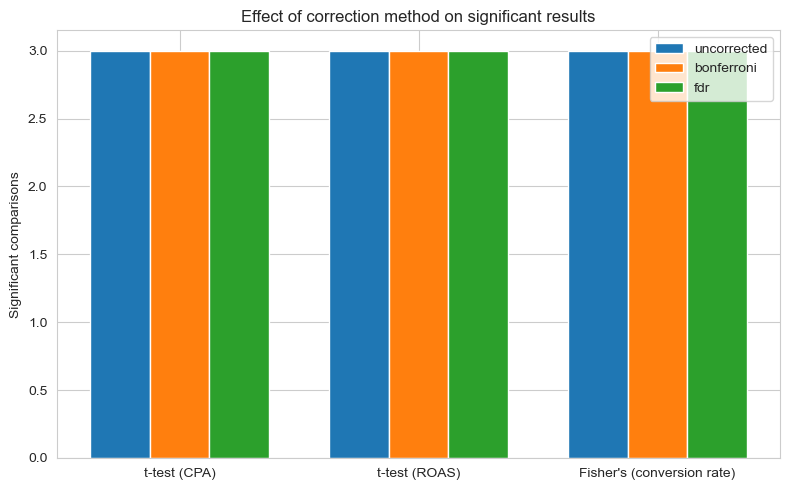

In [138]:
methods = ["uncorrected", "bonferroni", "fdr"]
x = np.arange(len(correction_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, method in enumerate(methods):
    ax.bar(x + i * width, correction_summary[method], width, label=method)

ax.set_xticks(x + width)
ax.set_xticklabels(correction_summary["test_type"])
ax.set_ylabel("Significant comparisons")
ax.set_title("Effect of correction method on significant results")
ax.legend()

plt.tight_layout()
plt.savefig("Outputs/correction_comparison.png", dpi=150)
plt.show()

## Part 4: Power Analysis & Sample Size Planning
### Step 7: Perform Power Analysis

In [139]:
def empirical_power_cpa(true_diff_pct, base_cpa, n_days, n_sim=1000, alpha=0.05):
    rejections = 0
    std = base_cpa * 0.15
    floor = base_cpa * 0.5

    for _ in range(n_sim):
        cpa_a = np.maximum(RNG.normal(base_cpa, std, n_days), floor)
        cpa_b = np.maximum(RNG.normal(base_cpa * (1 + true_diff_pct), std, n_days), floor)
        _, p_value = ttest_ind(cpa_a, cpa_b, equal_var=False)
        if p_value < alpha:
            rejections += 1

    return rejections / n_sim

In [140]:
effect_sizes = [0.05, 0.10, 0.15, 0.20]
sample_sizes = [30, 60, 90, 120, 180]
base_cpa = df["CPA"].mean()

power_rows = []
for effect in effect_sizes:
    for n_days in sample_sizes:
        power = empirical_power_cpa(effect, base_cpa, n_days, n_sim=500)
        power_rows.append({"effect_size_pct": effect, "n_days": n_days, "power": power})

power_df = pd.DataFrame(power_rows)

print("power to detect a CPA difference, by effect size (rows are days, columns are effect size)")
power_table = power_df.pivot(index="n_days", columns="effect_size_pct", values="power")
power_table.columns = [f"{c:.0%}" for c in power_table.columns]
power_table.round(3)

power to detect a CPA difference, by effect size (rows are days, columns are effect size)


,5%,10%,15%,20%
n_days,,,,
30,0.218,0.704,0.966,1.0
60,0.420,0.954,1.000,1.0
90,0.604,0.990,1.000,1.0
120,0.722,0.998,1.000,1.0
180,0.890,1.000,1.000,1.0


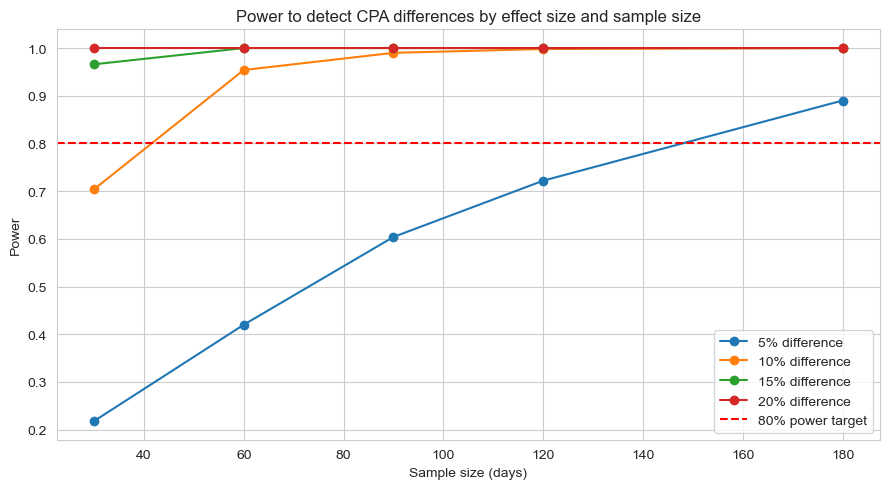

In [141]:
fig, ax = plt.subplots(figsize=(9, 5))

for effect in effect_sizes:
    subset = power_df[power_df["effect_size_pct"] == effect]
    ax.plot(subset["n_days"], subset["power"], marker="o", label=f"{effect:.0%} difference")

ax.axhline(0.8, color="red", linestyle="--", label="80% power target")
ax.set_xlabel("Sample size (days)")
ax.set_ylabel("Power")
ax.set_title("Power to detect CPA differences by effect size and sample size")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("Outputs/power_analysis_cpa.png", dpi=150)
plt.show()

In [142]:
target_power = 0.80
current_data_days = 90

min_days_rows = []
for effect in effect_sizes:
    subset = power_df[power_df["effect_size_pct"] == effect].sort_values("n_days")
    meets_target = subset[subset["power"] >= target_power]
    min_days = meets_target["n_days"].min() if len(meets_target) > 0 else None
    status = "not reached within tested sample sizes" if min_days is None else (
        "current data sufficient" if current_data_days >= min_days else "current data insufficient"
    )

    min_days_rows.append({
        "effect_size_pct": effect,
        "min_days_for_80pct_power": min_days,
        "current_data_sufficient": (min_days is not None) and (current_data_days >= min_days),
        "status": status,
    })

min_days_df = pd.DataFrame(min_days_rows)
min_days_df

,effect_size_pct,min_days_for_80pct_power,current_data_sufficient,status
0,0.05,180,False,current data insufficient
1,0.10,60,True,current data sufficient
2,0.15,30,True,current data sufficient
3,0.20,30,True,current data sufficient


In [143]:
fdr_significant_cpa = cpa_results[cpa_results["significant_fdr"]]
SEARCH_LIMIT_DAYS = 366

adequacy_rows = []
for _, row in fdr_significant_cpa.iterrows():
    smaller_mean = min(row["mean_a"], row["mean_b"])
    observed_relative_diff = abs(row["difference"]) / smaller_mean
    power_now = empirical_power_cpa(observed_relative_diff, smaller_mean, current_data_days, n_sim=500)

    if power_now >= 0.8:
        status = "already sufficient"
        days_needed = current_data_days
    else:
        # coarse pass in 15-day steps, then narrow to the nearest day once we bracket 80% power
        coarse_days = None
        for n_days in range(current_data_days, SEARCH_LIMIT_DAYS, 15):
            p = empirical_power_cpa(observed_relative_diff, smaller_mean, n_days, n_sim=500)
            if p >= 0.8:
                coarse_days = n_days
                break

        if coarse_days is None:
            status = f"not reached within {SEARCH_LIMIT_DAYS} days"
            days_needed = None
        else:
            days_needed = coarse_days
            for n_days in range(coarse_days - 14, coarse_days + 1):
                p = empirical_power_cpa(observed_relative_diff, smaller_mean, n_days, n_sim=500)
                if p >= 0.8:
                    days_needed = n_days
                    break
            status = "insufficient at 90 days, more data needed"

    adequacy_rows.append({
        "group_a": row["group_a"],
        "group_b": row["group_b"],
        "observed_relative_diff_pct": observed_relative_diff,
        "power_with_90_days": power_now,
        "days_needed_for_80pct_power": days_needed,
        "status": status,
    })

adequacy_df = pd.DataFrame(adequacy_rows)
adequacy_df.round(3)

,group_a,group_b,observed_relative_diff_pct,power_with_90_days,days_needed_for_80pct_power,status
0,Google Ads,Meta Ads,0.639,1.0,90,already sufficient
1,Google Ads,TikTok Ads,1.194,1.0,90,already sufficient
2,Meta Ads,TikTok Ads,0.339,1.0,90,already sufficient


## Part 5: Business Recommendations
### Step 8: Synthesize Findings and Create Recommendations

In [144]:
print("=== Significant CPA findings (FDR-corrected) ===")
for _, row in cpa_results[cpa_results["significant_fdr"]].iterrows():
    lower = row["group_b"] if row["difference"] < 0 else row["group_a"]
    higher = row["group_a"] if row["difference"] < 0 else row["group_b"]
    print(f"{lower} has lower CPA than {higher} by ${abs(row['difference']):.2f} "
          f"(FDR p={row['p_value_fdr']:.4g}, Cohen's d={row['cohens_d']:.2f}, {row['effect_size']})")

print()
print("=== Significant conversion rate findings (FDR-corrected) ===")
for _, row in fisher_results[fisher_results["significant_fdr"]].iterrows():
    higher = row["group_b"] if row["difference"] > 0 else row["group_a"]
    lower = row["group_a"] if row["difference"] > 0 else row["group_b"]
    print(f"{higher} has higher conversion rate than {lower} by {abs(row['difference']):.2%} "
          f"(FDR p={row['p_value_fdr']:.4g})")

=== Significant CPA findings (FDR-corrected) ===
Meta Ads has lower CPA than Google Ads by $24.97 (FDR p=1.121e-27, Cohen's d=-0.60, medium)
TikTok Ads has lower CPA than Google Ads by $34.87 (FDR p=8.176e-51, Cohen's d=-0.88, large)
TikTok Ads has lower CPA than Meta Ads by $9.90 (FDR p=6.494e-09, Cohen's d=-0.35, small)

=== Significant conversion rate findings (FDR-corrected) ===
Meta Ads has higher conversion rate than Google Ads by 0.12% (FDR p=2.416e-09)
TikTok Ads has higher conversion rate than Google Ads by 0.24% (FDR p=1.588e-42)
TikTok Ads has higher conversion rate than Meta Ads by 0.12% (FDR p=9.537e-09)


In [145]:
def bootstrap_ci(data, n_bootstrap=1000, ci_level=0.95):
    means = [RNG.choice(data, size=len(data), replace=True).mean() for _ in range(n_bootstrap)]
    lower_pct = (1 - ci_level) / 2 * 100
    upper_pct = (1 - (1 - ci_level) / 2) * 100
    return np.percentile(means, lower_pct), np.percentile(means, upper_pct)


ci_rows = []
for platform in sorted(df["platform"].unique()):
    cpa_values = df[df["platform"] == platform]["CPA"].dropna().values
    lower, upper = bootstrap_ci(cpa_values)
    ci_rows.append({
        "platform": platform,
        "mean_cpa": cpa_values.mean(),
        "ci_lower": lower,
        "ci_upper": upper,
    })

ci_df = pd.DataFrame(ci_rows)
ci_df.round(2)

,platform,mean_cpa,ci_lower,ci_upper
0,Google Ads,64.06,60.52,67.55
1,Meta Ads,39.10,36.82,41.58
2,TikTok Ads,29.20,26.99,31.69


In [146]:
MONTHLY_BUDGET = 500_000
MIN_ALLOCATION_PCT = 0.15
MAX_ALLOCATION_PCT = 0.55

platform_cpa_roas = df.groupby("platform").agg(CPA=("CPA", "mean"), ROAS=("ROAS", "mean")).reset_index()

rank_df = platform_cpa_roas.copy()
rank_df["cpa_rank"] = rank_df["CPA"].rank(ascending=True)
rank_df["roas_rank"] = rank_df["ROAS"].rank(ascending=False)
rank_df["composite_score"] = (rank_df["cpa_rank"] * 0.5) + (rank_df["roas_rank"] * 0.5)
rank_df = rank_df.sort_values("composite_score")

rank_df["inverse_score"] = rank_df["composite_score"].max() + 1 - rank_df["composite_score"]
rank_df["raw_allocation_pct"] = rank_df["inverse_score"] / rank_df["inverse_score"].sum()
rank_df["allocation_pct"] = rank_df["raw_allocation_pct"].clip(MIN_ALLOCATION_PCT, MAX_ALLOCATION_PCT)
rank_df["allocation_pct"] = rank_df["allocation_pct"] / rank_df["allocation_pct"].sum()
rank_df["allocation_amount"] = rank_df["allocation_pct"] * MONTHLY_BUDGET

allocation_table = rank_df[["platform", "CPA", "ROAS", "composite_score", "allocation_pct", "allocation_amount"]]
allocation_table.round(2)

,platform,CPA,ROAS,composite_score,allocation_pct,allocation_amount
2,TikTok Ads,29.20,9.54,1.0,0.50,250000.00
1,Meta Ads,39.10,6.92,2.0,0.33,166666.67
0,Google Ads,64.06,4.11,3.0,0.17,83333.33
